# Cosine Similarity

## Goal
How do we measure the distance between words in vector space?
Euclidean distance is sensitive to vector magnitude.
Cosine similarity measures the angle between vectors - not the distance.
This makes it much better for comparing text.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

## 1. Cosine Similarity Formula
cos(A, B) = (A . B) / (||A|| * ||B||)

Result is between -1 and 1:
- 1.0 = identical direction - very similar
- 0.0 = perpendicular - no similarity
- -1.0 = opposite direction - completely different

In [5]:
def cosine_sim(vec_a: np.ndarray, vec_b: np.ndarray) -> float:
    """Calculate cosine similarity between two vectors."""
    dot_product = np.dot(vec_a, vec_b)
    magnitude = np.linalg.norm(vec_a) * np.linalg.norm(vec_b)
    if magnitude == 0:
        return 0.0
    return dot_product / magnitude

# Word vectors from previous notebook
word_vectors = {
    "king":     np.array([1.0, 1.0, 0.8]),
    "queen":    np.array([1.0, 0.0, 0.8]),
    "man":      np.array([0.0, 1.0, 0.5]),
    "woman":    np.array([0.0, 0.0, 0.5]),
    "boy":      np.array([0.0, 1.0, 0.0]),
    "girl":     np.array([0.0, 0.0, 0.0]),
    "prince":   np.array([0.8, 1.0, 0.2]),
    "princess": np.array([0.8, 0.0, 0.2]),
}

# Test pairs
pairs = [
    ("king", "queen"),
    ("king", "prince"),
    ("man", "woman"),
    ("king", "girl"),
    ("boy", "girl"),
]

print(f"{"Pair":<25} {"Cosine Similarity":>18}")
print("-" * 45)
for word_a, word_b in pairs:
    sim = cosine_sim(word_vectors[word_a], word_vectors[word_b])
    print(f"{word_a + "vs" + word_b:<25} {sim:>18.4f}")

Pair                       Cosine Similarity
---------------------------------------------
kingvsqueen                           0.7882
kingvsprince                          0.9307
manvswoman                            0.4472
kingvsgirl                            0.0000
boyvsgirl                             0.0000


## 2. Similarity Heatmap
Visualize all pairwise similarities at once

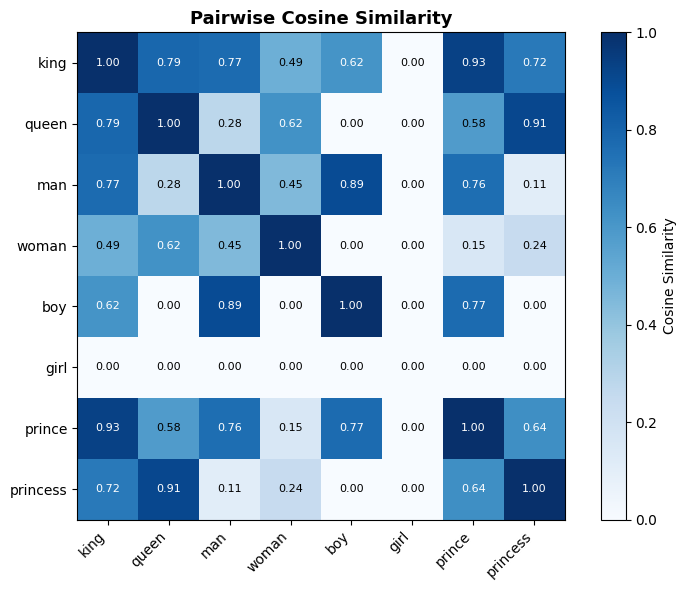

In [7]:
words = list(word_vectors.keys())
vectors = np.array(list(word_vectors.values()))

# Compute full similarity matrix
sim_matrix = cosine_similarity(vectors)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels(words, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(words, fontsize=10)

for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
               color="white" if sim_matrix[i, j] > 0.6 else "black")

plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title("Pairwise Cosine Similarity", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cosine_similarity_heatmap.png", dpi=300)
plt.show()

## 3. Key Observations

| Pair | Similarity | Reason |
|------|-----------|--------|
| king vs prince | 0.93 | both male royalty |
| queen vs princess | 0.91 | both female royalty |
| man vs boy | 0.89 | both male commoners |
| king vs queen | 0.79 | both royalty, different gender |
| girl vs everything | 0.00 | vector is [0,0,0] — a limitation of manual vectors |

## Key Insight
Cosine similarity captures relationships, not just raw closeness.
Two vectors can be far apart in space but still point in the same direction.

## Limitation
girl = [0, 0, 0] — a zero vector has no direction.
This is an artifact of our manual vectors, not a real property of the word.
In real embeddings (Word2Vec, GloVe), no word has a zero vector.

## Next
How does a model decide which words to focus on?
-> 06_attention_intuition.ipynb